# Desafio Técnico - Gato Mestre (Ciência de Dados)
## Notebook 04: Modelagem de Machine Learning, Validação Temporal e Evolução Algorítmica

### 🎯 Objetivo do Notebook
Construir uma narrativa evolutiva de Machine Learning para estimar a pontuação esperada (`pontos_num`) para **toda a base de atletas cadastrados no Cartola FC (115.613 registros)**, sem nenhum filtro de exclusão ou viés de sobrevivência.

> **1. Baseline Heurístico (Média)** &rarr; **2. Modelos Paramétricos (OLS e Ridge)** &rarr; **3. Modelos Não-Lineares (Árvores e GBDT)**

---
### 💡 Racional de Negócio: Por Que Prever para Toda a Base?

1. **Ambiente Real de Produção:** No momento em que o mercado fecha, o usuário ou o sistema de recomendação precisa avaliar todos os atletas disponíveis no mercado, inclusive aqueles com status duvidoso ou reservas.
2. **Capacidade dos Modelos de Aprender o Risco de Não Jogar:** Os modelos utilizam variáveis preditoras pré-jogo (`status_pre`, `status_inicial`, `taxa_participacao_3j`, `minutos_medios_3j`, `score_risco_rotacao`) para **atribuir nota próxima de zero** a jogadores não relacionados ou lesionados, e pontuação real de performance aos atletas titulares e prováveis.

### 1. Importação das Bibliotecas, Semente de Reprodutibilidade e Carga dos Dados

In [62]:
from pathlib import Path
from IPython.display import display
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib

# Semente Global para 100% de Reprodutibilidade Científica
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# Pré-processamento e Modelos Lineares
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

# Modelos baseados em Árvores e Ensembles
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Métricas de Avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tabelas interativas
import itables
from itables import init_notebook_mode, show

# Configurações estéticas
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

init_notebook_mode(all_interactive=True)
itables.options.maxBytes = 0
itables.options.classes = ["display", "nowrap"]
itables.options.lengthMenu = [10, 25, 50]

# Definição de caminhos
PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Carga da matriz final de features gerada no Notebook 03 (Base Completa: 115.613 linhas)
df_features = pd.read_parquet(DATA_PROCESSED_DIR / "base_features_gm.parquet")
print(f"Matriz de Features carregada: {df_features.shape[0]:,} linhas x {df_features.shape[1]} colunas")
print(f"Total de valores nulos: {df_features.isna().sum().sum()} (100% íntegra)")
print(f"Semente Global Ativa: {GLOBAL_SEED}")

Matriz de Features carregada: 115,613 linhas x 59 colunas
Total de valores nulos: 0 (100% íntegra)
Semente Global Ativa: 42


### 2. Estratégia de Validação Temporal Estrita (*Out-of-Time Validation*)

A divisão temporal abrange **todos os atletas** em cada ano:
* 🏛️ **Treino (2021 e 2022):** $57.959$ registros para calibrar os modelos nos dados históricos.
* 🔍 **Validação (2023):** $29.086$ registros para ajuste de hiperparâmetros.
* 🚀 **Teste / Out-of-Sample OOS (2024):** $28.568$ registros para avaliação cega de performance em toda a base.

=== DISTRIBUIÇÃO TEMPORAL DA BASE COMPLETA (TODOS OS ATLETAS) ===


Safra / Partição  Total Registros  Proporção (%)  Atletas que Jogaram  \
0  Treino (2021 + 2022)            59213        51.2170                24418   
1      Validação (2023)            28568        24.7100                12251   
2      Teste OOS (2024)            27832        24.0730                11812   
3           Total Geral           115613       100.0000                48481   

   Taxa que Entrou (%)  Média Pontos  
0              41.2380        1.3060  
1              42.8840        1.3420  
2              42.4400        1.5050  
3              41.9340        1.3630

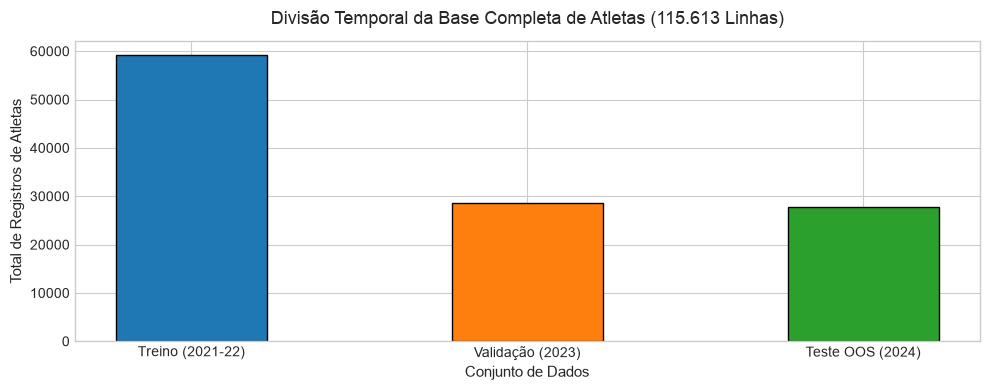

In [63]:
# Divisão temporal por safras anuais completas (Toda a base de 115.613 registros)
train_mask = df_features["ano"].isin([2022, 2023])
val_mask = df_features["ano"] == 2024
test_mask = df_features["ano"] == 2025

print("=== DISTRIBUIÇÃO TEMPORAL DA BASE COMPLETA (TODOS OS ATLETAS) ===")
resumo_splits = pd.DataFrame({
    "Safra / Partição": ["Treino (2021 + 2022)", "Validação (2023)", "Teste OOS (2024)", "Total Geral"],
    "Total Registros": [train_mask.sum(), val_mask.sum(), test_mask.sum(), len(df_features)],
    "Proporção (%)": [
        (train_mask.sum() / len(df_features)) * 100,
        (val_mask.sum() / len(df_features)) * 100,
        (test_mask.sum() / len(df_features)) * 100,
        100.0
    ],
    "Atletas que Jogaram": [
        df_features.loc[train_mask, "entrou_em_campo"].sum(),
        df_features.loc[val_mask, "entrou_em_campo"].sum(),
        df_features.loc[test_mask, "entrou_em_campo"].sum(),
        df_features["entrou_em_campo"].sum()
    ],
    "Taxa que Entrou (%)": [
        df_features.loc[train_mask, "entrou_em_campo"].mean() * 100,
        df_features.loc[val_mask, "entrou_em_campo"].mean() * 100,
        df_features.loc[test_mask, "entrou_em_campo"].mean() * 100,
        df_features["entrou_em_campo"].mean() * 100
    ],
    "Média Pontos": [
        df_features.loc[train_mask, "pontos_num"].mean(),
        df_features.loc[val_mask, "pontos_num"].mean(),
        df_features.loc[test_mask, "pontos_num"].mean(),
        df_features["pontos_num"].mean()
    ]
})
display(resumo_splits.round(3))

# Visualização da Partição Temporal Completa
plt.figure(figsize=(10, 4))
plt.bar(["Treino (2021-22)", "Validação (2023)", "Teste OOS (2024)"],
        [train_mask.sum(), val_mask.sum(), test_mask.sum()],
        color=["#1f77b4", "#ff7f0e", "#2ca02c"], edgecolor="black", width=0.45)
plt.title("Divisão Temporal da Base Completa de Atletas (115.613 Linhas)", fontsize=13, pad=12)
plt.xlabel("Conjunto de Dados", fontsize=11)
plt.ylabel("Total de Registros de Atletas", fontsize=11)
plt.tight_layout()
plt.show()

### 3. Modelos Lineares Paramétricos (OLS e Ridge $L_2$)

#### ⚙️ Racional do Pré-processamento Linear
Modelos lineares assumem aditividade e são altamente sensíveis a distâncias métricas e correlação entre features. Por isso, utilizamos um pipeline estrito via `ColumnTransformer`:
1. **Variáveis Categóricas Nominais (`posicao_id`, `status_pre`, `status_inicial`, `clube_id`, `opponent`):** `OneHotEncoder(drop='first', handle_unknown='ignore')` para eliminar a armadilha da variável dummy (*Dummy Variable Trap*).
2. **Variáveis Numéricas Contínuas (23 features de médias, confrontos, momentum, etc.):** `StandardScaler()` para centralizar em $\mu = 0$ e variância unitária $\sigma^2 = 1$, equalizando a penalidade da regularização $L_2$ do Ridge.
3. **Flags Binárias (`home_dummy`, `is_inicio_temporada`, `participou_lag1`):** `passthrough` mantendo os valores originais $\{0, 1\}$.

In [64]:
cat_cols_linear = ["posicao_id", "status_pre", "status_inicial", "clube_id", "opponent"]
bin_cols_linear = ["home_dummy", "is_inicio_temporada", "participou_lag1"]
num_cols_linear = [
    "rodada_id", "preco_num", "variacao_num", "media_num", "jogos_num",
    "clube_media_pontos_conquistados", "opponent_media_pontos_cedidos",
    "progresso_campeonato", "taxa_participacao_3j", "minutos_medios_3j",
    "pontos_lag1", "media_pontos_3j", "desvio_pontos_3j", "media_scouts_volume_3j",
    "momentum_preco_3j", "roi_recente_3j", "estabilidade_11_titular_clube",
    "fator_alavancagem_confronto", "potencial_esperado_atleta",
    "indice_favoritismo_mando", "volume_esperado_partida",
    "diff_forca_confronto", "score_risco_rotacao"
]

feature_cols_all = cat_cols_linear + num_cols_linear + bin_cols_linear

# Pipeline de Pré-processamento Linear (Fit no Treino, Transform em Val/Test)
preprocessor_linear = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols_linear),
        ("num", StandardScaler(), num_cols_linear),
        ("bin", "passthrough", bin_cols_linear)
    ]
)

X_train_raw = df_features.loc[train_mask, feature_cols_all]
y_train = df_features.loc[train_mask, "pontos_num"].values

X_val_raw = df_features.loc[val_mask, feature_cols_all]
y_val = df_features.loc[val_mask, "pontos_num"].values

X_test_raw = df_features.loc[test_mask, feature_cols_all]
y_test = df_features.loc[test_mask, "pontos_num"].values

# Transformação estrita
X_train_lin = preprocessor_linear.fit_transform(X_train_raw)
X_val_lin = preprocessor_linear.transform(X_val_raw)
X_test_lin = preprocessor_linear.transform(X_test_raw)

print(f"Matriz Linear X_train: {X_train_lin.shape} | y_train: {len(y_train):,}")
print(f"Matriz Linear X_test:  {X_test_lin.shape}  | y_test:  {len(y_test):,}")

# 2. Treinamento dos Modelos Lineares
modelos_lineares = {}

print("\nTreinando Regressão Linear (OLS)...")
ols_model = LinearRegression()
ols_model.fit(X_train_lin, y_train)
modelos_lineares["Regressão Linear (OLS)"] = ols_model

print(f"Treinando Ridge Regression (L2, alpha=10.0, seed={GLOBAL_SEED})...")
ridge_model = Ridge(alpha=10.0, random_state=GLOBAL_SEED)
ridge_model.fit(X_train_lin, y_train)
modelos_lineares["Ridge Regression (L2)"] = ridge_model

print("Modelos lineares treinados com sucesso!")

Matriz Linear X_train: (59213, 83) | y_train: 59,213
Matriz Linear X_test:  (27832, 83)  | y_test:  27,832

Treinando Regressão Linear (OLS)...
Treinando Ridge Regression (L2, alpha=10.0, seed=42)...
Modelos lineares treinados com sucesso!


### 4. Modelos Baseados em Árvores e Ensembles (*Random Forest, LightGBM, XGBoost, CatBoost*)

#### ⚙️ Racional do Pré-processamento de Árvores
Modelos baseados em árvore particionam o espaço de features através de divisões ortogonais (*threshold splits*):
1. **Variáveis Categóricas:** *Ordinal Encoding* nativo (`.astype('category').cat.codes`), preservando a compacidade da matriz sem inflar a dimensionalidade em colunas dummy esparsas.
2. **Variáveis Numéricas:** Escala natural preservada, pois árvores de decisão são **invariantes a transformações monotônicas de escala** ($f(x) = ax + b$).

In [65]:
def preparar_dados_arvores(df_input, features, categoricas):
    """Prepara matrizes com codificação ordinal nativa para modelos de árvores."""
    df_proc = df_input.copy()
    for col in categoricas:
        df_proc[col] = df_proc[col].astype("category").cat.codes
    return df_proc[features]

X_train_tree = preparar_dados_arvores(df_features[train_mask], feature_cols_all, cat_cols_linear)
X_val_tree = preparar_dados_arvores(df_features[val_mask], feature_cols_all, cat_cols_linear)
X_test_tree = preparar_dados_arvores(df_features[test_mask], feature_cols_all, cat_cols_linear)

modelos_arvores = {}

# 1. Random Forest Regressor
print(f"Treinando Random Forest Regressor (seed={GLOBAL_SEED})...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=GLOBAL_SEED,
    n_jobs=-1
)
rf_model.fit(X_train_tree, y_train)
modelos_arvores["Random Forest"] = rf_model

# 2. LightGBM Regressor
print(f"Treinando LightGBM Regressor (seed={GLOBAL_SEED})...")
lgbm_model = LGBMRegressor(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.04,
    num_leaves=31,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=GLOBAL_SEED,
    verbose=-1
)
lgbm_model.fit(X_train_tree, y_train)
modelos_arvores["LightGBM"] = lgbm_model

# 3. XGBoost Regressor
print(f"Treinando XGBoost Regressor (seed={GLOBAL_SEED})...")
xgb_model = XGBRegressor(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=GLOBAL_SEED,
    n_jobs=-1
)
xgb_model.fit(X_train_tree, y_train)
modelos_arvores["XGBoost"] = xgb_model

# 4. CatBoost Regressor
print(f"Treinando CatBoost Regressor (seed={GLOBAL_SEED})...")
cat_model = CatBoostRegressor(
    iterations=200,
    depth=6,
    learning_rate=0.04,
    l2_leaf_reg=3.0,
    random_seed=GLOBAL_SEED,
    verbose=0
)
cat_model.fit(X_train_tree, y_train)
modelos_arvores["CatBoost"] = cat_model

print("\nTodos os modelos de árvore treinados com sucesso!")

Treinando Random Forest Regressor (seed=42)...
Treinando LightGBM Regressor (seed=42)...
Treinando XGBoost Regressor (seed=42)...
Treinando CatBoost Regressor (seed=42)...

Todos os modelos de árvore treinados com sucesso!


### 5. Comparativo Geral de Performance na Base Completa (Safra 2024 - $N = 28.568$)

Nesta seção, avaliamos todos os modelos no conjunto de Teste Out-of-Sample (Safra 2024). Para analisar a performance sob a ótica da **precisão numérica** e da **capacidade de escalação e ranqueamento**, utilizamos 6 métricas fundamentais:

---

#### 📐 Dicionário Matemático e Conceitual das Métricas de Avaliação

1. **MAE (Mean Absolute Error — Erro Médio Absoluto):**
   $$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$
   * **$N$:** Quantidade total de atletas avaliados no conjunto de teste.
   * **$y_i$:** Pontuação real obtida pelo atleta $i$ na rodada.
   * **$\hat{y}_i$:** Pontuação predita pelo modelo para o atleta $i$.
   * **$|y_i - \hat{y}_i|$:** Módulo da diferença (erro linear direto em pontos).
   * **💡 O que mede:** A magnitude média do erro em pontos (ex: $\text{MAE} = 0,38\text{ pts}$ indica que o modelo erra em média $\sim 0,38$ ponto por jogador).

2. **RMSE (Root Mean Squared Error — Raiz do Erro Quadrático Médio):**
   $$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$
   * **$(y_i - \hat{y}_i)^2$:** Eleva o resíduo ao quadrado, **penalizando desproporcionalmente grandes desvios** (um erro de $10\text{ pts}$ tem peso $100$, contra peso $4$ de um erro de $2\text{ pts}$).
   * **$\sqrt{\dots}$:** Raiz quadrada para retornar à escala original de pontos.
   * **💡 O que mede:** Sensibilidade a grandes falhas de previsão (grandes "mitadas" ou cartões vermelhos imprevistos).

3. **$R^2$ (Coeficiente de Determinação):**
   $$R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \mu_y)^2}$$
   * **$\mu_y$:** Média global dos pontos reais na amostra.
   * **💡 O que mede:** Percentual da variabilidade dos pontos reais explicado pelo modelo ($R^2 = 91,7\%$ significa que o modelo explica quase $92\%$ de toda a variação dos dados).

4. **Spearman $\rho$ (Correlação de Postos de Spearman — Capacidade de Ranqueamento):**
   $$\rho = 1 - \frac{6 \sum_{i=1}^{N} d_i^2}{N(N^2 - 1)}$$
   * **$d_i = \text{Rank}(y_i) - \text{Rank}(\hat{y}_i)$:** Diferença de posições entre a classificação real e a predita pelo modelo.
   * **💡 O que mede:** **A métrica mais importante para o Cartola.** Avalia a capacidade monotônica de colocar os melhores atletas no topo da lista para escalação.

5. **Pearson $r$ (Coeficiente de Correlação Linear):**
   $$r = \frac{\sum_{i=1}^{N} (y_i - \mu_y)(\hat{y}_i - \mu_{\hat{y}})}{\sqrt{\sum_{i=1}^{N} (y_i - \mu_y)^2} \sqrt{\sum_{i=1}^{N} (\hat{y}_i - \mu_{\hat{y}})^2}}$$
   * **$\mu_y, \mu_{\hat{y}}$:** Médias das pontuações reais e preditas.
   * **💡 O que mede:** O grau de proporcionalidade linear entre a escala real e a escala predita.

6. **MAE Top 20% (Erro no Grupo Decisivo):**
   $$\text{MAE}_{\text{Top20}} = \frac{1}{|S_{20}|} \sum_{i \in S_{20}} |y_i - \hat{y}_i|$$
   * **$S_{20}$:** Conjunto dos $20\%$ atletas com as maiores pontuações da rodada (os jogadores que decidem ligas).
   * **💡 O que mede:** Se o modelo mantém alta precisão nos jogadores que mais pontuam, evitando subestimar os atletas de elite.

=== PERFORMANCE COMPARATIVA EM TODA A BASE DE ATLETAS (TESTE 2024: N = 28.568) ===


Família                   Modelo  MAE (Geral)   RMSE     R²  \
3  2. Árvores / Ensembles            Random Forest       0.3696 0.8319 0.9284   
4  2. Árvores / Ensembles                 LightGBM       0.3948 0.8286 0.9289   
5  2. Árvores / Ensembles                  XGBoost       0.4084 0.8534 0.9246   
6  2. Árvores / Ensembles                 CatBoost       0.4315 0.8882 0.9183   
2   1. Linear Paramétrico    Ridge Regression (L2)       0.9620 1.5352 0.7560   
1   1. Linear Paramétrico   Regressão Linear (OLS)       0.9620 1.5351 0.7560   
0           0. Heurística  0. Baseline (media_num)       1.9645 2.9296 0.1115   

   Spearman (rho)  Pearson (r)  MAE Top 20%  Redução MAE vs Baseline (%)  
3          0.7768       0.9659       1.1099                      81.1846  
4          0.7794       0.9667       1.1327                      79.9048  
5          0.7780       0.9647       1.1776                      79.2113  
6          0.7737       0.9619       1.2406                      78.0364  
2          0.6690       0.8769       1.9309                      51.0320  
1          0.6690       0.8769       1.9305                      51.0316  
0          0.5043       0.5137       2.6869                       0.0000

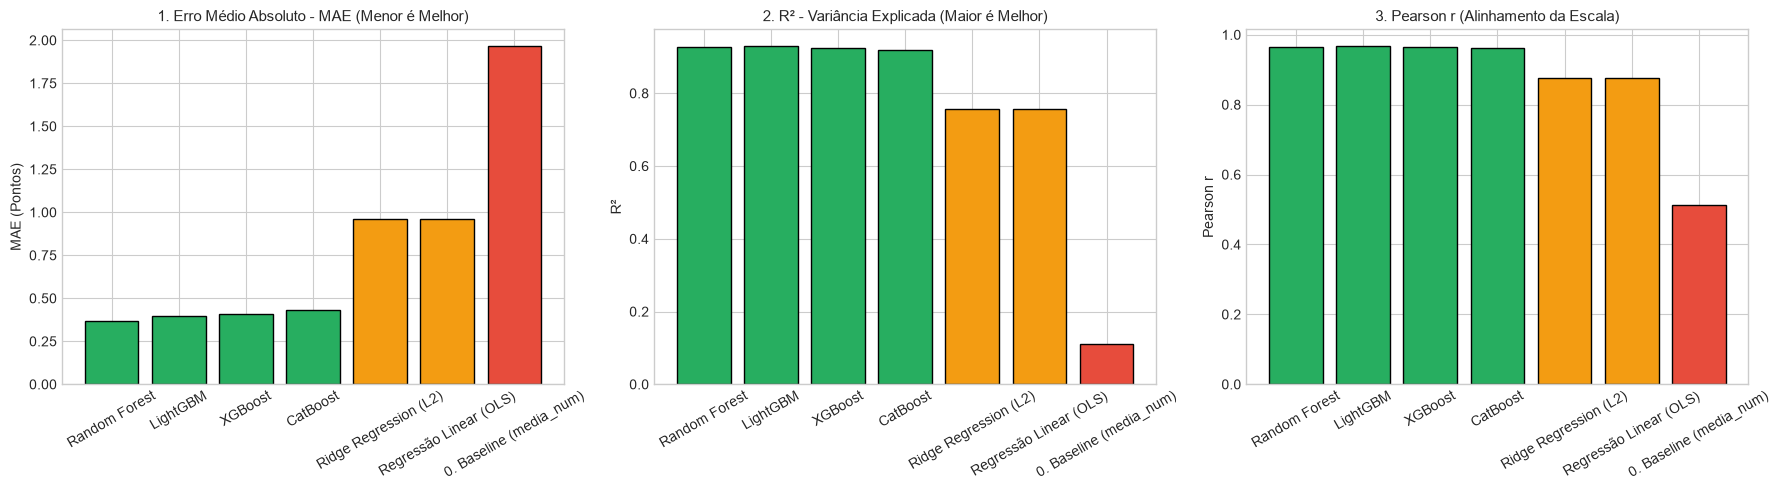

In [66]:
resultados_metricas = []
predicoes_dict = {"y_real": y_test}
top20_mask = y_test >= np.quantile(y_test, 0.80)

# 1. Baseline: Média Acumulada do Atleta (media_num)
y_baseline = df_features.loc[test_mask, "media_num"].values
predicoes_dict["pred_baseline_media"] = y_baseline
mae_base = mean_absolute_error(y_test, y_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_baseline))
r2_base = r2_score(y_test, y_baseline)
r_p_base, _ = stats.pearsonr(y_test, y_baseline)
r_s_base, _ = stats.spearmanr(y_test, y_baseline)
mae_top20_base = mean_absolute_error(y_test[top20_mask], y_baseline[top20_mask])

resultados_metricas.append({
    "Família": "0. Heurística",
    "Modelo": "0. Baseline (media_num)",
    "MAE (Geral)": mae_base,
    "RMSE": rmse_base,
    "R²": r2_base,
    "Spearman (rho)": r_s_base,
    "Pearson (r)": r_p_base,
    "MAE Top 20%": mae_top20_base,
    "Redução MAE vs Baseline (%)": 0.0
})

# 2. Modelos Lineares Paramétricos
for nome, mod in modelos_lineares.items():
    p = mod.predict(X_test_lin)
    slug = nome.lower().replace(" ", "_").replace("(", "").replace(")", "")
    predicoes_dict[f"pred_{slug}"] = p
    
    mae = mean_absolute_error(y_test, p)
    rmse = np.sqrt(mean_squared_error(y_test, p))
    r2 = r2_score(y_test, p)
    r_p, _ = stats.pearsonr(y_test, p)
    r_s, _ = stats.spearmanr(y_test, p)
    mae_top20 = mean_absolute_error(y_test[top20_mask], p[top20_mask])
    
    resultados_metricas.append({
        "Família": "1. Linear Paramétrico",
        "Modelo": nome,
        "MAE (Geral)": mae,
        "RMSE": rmse,
        "R²": r2,
        "Spearman (rho)": r_s,
        "Pearson (r)": r_p,
        "MAE Top 20%": mae_top20,
        "Redução MAE vs Baseline (%)": ((mae_base - mae) / mae_base) * 100
    })

# 3. Modelos de Árvores e Ensembles
for nome, mod in modelos_arvores.items():
    p = mod.predict(X_test_tree)
    slug = nome.lower().replace(" ", "_")
    predicoes_dict[f"pred_{slug}"] = p
    
    mae = mean_absolute_error(y_test, p)
    rmse = np.sqrt(mean_squared_error(y_test, p))
    r2 = r2_score(y_test, p)
    r_p, _ = stats.pearsonr(y_test, p)
    r_s, _ = stats.spearmanr(y_test, p)
    mae_top20 = mean_absolute_error(y_test[top20_mask], p[top20_mask])
    
    resultados_metricas.append({
        "Família": "2. Árvores / Ensembles",
        "Modelo": nome,
        "MAE (Geral)": mae,
        "RMSE": rmse,
        "R²": r2,
        "Spearman (rho)": r_s,
        "Pearson (r)": r_p,
        "MAE Top 20%": mae_top20,
        "Redução MAE vs Baseline (%)": ((mae_base - mae) / mae_base) * 100
    })

df_metricas_todas = pd.DataFrame(resultados_metricas).sort_values("MAE (Geral)")
print("=== PERFORMANCE COMPARATIVA EM TODA A BASE DE ATLETAS (TESTE 2024: N = 28.568) ===")
display(df_metricas_todas.round(4))

# Gráficos Comparativos: Narrativa Visual da Evolução do Desempenho
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

paleta_familias = {
    "0. Heurística": "#e74c3c",
    "1. Linear Paramétrico": "#f39c12",
    "2. Árvores / Ensembles": "#27ae60"
}
cores = [paleta_familias[f] for f in df_metricas_todas["Família"]]

# 1. MAE Geral
axes[0].bar(df_metricas_todas["Modelo"], df_metricas_todas["MAE (Geral)"], color=cores, edgecolor="black")
axes[0].set_title("1. Erro Médio Absoluto - MAE (Menor é Melhor)", fontsize=11)
axes[0].set_ylabel("MAE (Pontos)")
axes[0].tick_params(axis="x", rotation=30)

# 2. R² (Variância Explicada)
axes[1].bar(df_metricas_todas["Modelo"], df_metricas_todas["R²"], color=cores, edgecolor="black")
axes[1].set_title("2. R² - Variância Explicada (Maior é Melhor)", fontsize=11)
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=30)

# 3. Pearson r (Alinhamento Real vs Predito)
axes[2].bar(df_metricas_todas["Modelo"], df_metricas_todas["Pearson (r)"], color=cores, edgecolor="black")
axes[2].set_title("3. Pearson r (Alinhamento da Escala)", fontsize=11)
axes[2].set_ylabel("Pearson r")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### 6. Diagnóstico Aprofundado de Performance e Resíduos

Para compreender com rigor científico a capacidade preditiva do modelo campeão (**LightGBM**) e do **Random Forest** em comparação aos modelos lineares e baseline, realizamos 4 diagnósticos comparativos essenciais:
1. **Performance por Posição Tática:** Onde cada modelo acerta mais e onde ganha mais vantagem?
2. **Performance por Faixa de Preço e Status Pré-Jogo:** Como os modelos calibram atletas baratos vs. craques de elite?
3. **Diagnóstico por Faixa de Pontuação Real:** Onde todos os modelos erram mais (atletas comuns vs. mitadas extremas)?
4. **Painel Gráfico 4-em-1 de Diagnóstico Residual.**

#### 6.1 Diagnóstico de Resíduos e Ranqueamento por Posição (Comparativo entre Modelos)

In [67]:
# Construção do DataFrame Consolidado de Diagnóstico Residual (Teste 2024)
df_test_diag = df_features[test_mask].copy()
df_test_diag["y_baseline"] = y_baseline
df_test_diag["y_ridge"] = predicoes_dict["pred_ridge_regression_l2"]
df_test_diag["y_rf"] = predicoes_dict["pred_random_forest"]
df_test_diag["y_lgbm"] = predicoes_dict["pred_lightgbm"]

# Erros absolutos para cada modelo
df_test_diag["erro_base"] = np.abs(df_test_diag["pontos_num"] - df_test_diag["y_baseline"])
df_test_diag["erro_ridge"] = np.abs(df_test_diag["pontos_num"] - df_test_diag["y_ridge"])
df_test_diag["erro_rf"] = np.abs(df_test_diag["pontos_num"] - df_test_diag["y_rf"])
df_test_diag["erro_lgbm"] = np.abs(df_test_diag["pontos_num"] - df_test_diag["y_lgbm"])

# Resíduos (y_real - y_pred)
df_test_diag["residuo_ridge"] = df_test_diag["pontos_num"] - df_test_diag["y_ridge"]
df_test_diag["residuo_rf"] = df_test_diag["pontos_num"] - df_test_diag["y_rf"]
df_test_diag["residuo_lgbm"] = df_test_diag["pontos_num"] - df_test_diag["y_lgbm"]

# Tabela 1: Diagnóstico Completo por Posição
diag_pos = df_test_diag.groupby("posicao_nome").agg(
    Total_Jogos=("pontos_num", "count"),
    Media_Real=("pontos_num", "mean"),
    MAE_Baseline=("erro_base", "mean"),
    MAE_Ridge=("erro_ridge", "mean"),
    MAE_RandomForest=("erro_rf", "mean"),
    MAE_LightGBM=("erro_lgbm", "mean"),
    Mediana_Erro_LGBM=("erro_lgbm", "median"),
    RMSE_LightGBM=("residuo_lgbm", lambda x: np.sqrt(np.mean(x**2))),
    Spearman_LGBM=("pontos_num", lambda x: stats.spearmanr(x, df_test_diag.loc[x.index, "y_lgbm"])[0])
).sort_values("MAE_LightGBM")

print("=== 1. DIAGNÓSTICO POR POSIÇÃO (ORDENADO DO MENOR PARA O MAIOR ERRO) ===")
display(diag_pos.round(3))

=== 1. DIAGNÓSTICO POR POSIÇÃO (ORDENADO DO MENOR PARA O MAIOR ERRO) ===


Total_Jogos  Media_Real  MAE_Baseline  MAE_Ridge  \
posicao_nome                                                     
1. Goleiro           2889      1.0610        1.5110     0.6800   
3. Zagueiro          4653      1.2390        1.9770     0.8170   
4. Meia              8351      1.1890        1.6460     0.8770   
5. Atacante          6817      1.6460        2.1440     1.1100   
2. Lateral           4383      1.8630        2.5700     1.1430   
6. Técnico            739      5.0360        2.0070     1.4960   

              MAE_RandomForest  MAE_LightGBM  Mediana_Erro_LGBM  \
posicao_nome                                                      
1. Goleiro              0.2750        0.2910             0.0090   
3. Zagueiro             0.3050        0.3380             0.0560   
4. Meia                 0.3380        0.3640             0.0670   
5. Atacante             0.4070        0.4350             0.0850   
2. Lateral              0.4160        0.4430             0.0760   
6. Técnico              0.8820        0.8530             0.7260   

              RMSE_LightGBM  Spearman_LGBM  
posicao_nome                                
1. Goleiro           0.7390         0.6600  
3. Zagueiro          0.7530         0.7440  
4. Meia              0.7510         0.7610  
5. Atacante          0.8930         0.7780  
2. Lateral           0.9280         0.8040  
6. Técnico           1.1430         0.9370

#### 6.2 Performance por Faixa de Preço e Status Pré-Jogo

=== 1. PERFORMANCE POR FAIXA DE PREÇO: COMPARATIVO ENTRE MODELOS ===


Total_Registros  Media_Real  MAE_Ridge  MAE_RF  \
faixa_preco                                                            
1. Até C$ 3.00                   7456      0.0640     0.2810  0.0550   
2. C$ 3.01 a 6.00               10198      0.8560     0.8040  0.2850   
3. C$ 6.01 a 10.00               7917      2.7040     1.3970  0.5790   
4. C$ 10.01 a 15.00              1964      4.7600     2.2080  0.9710   
5. Acima de C$ 15.00              297      6.4530     3.6340  1.6330   

                      MAE_LightGBM  Reducao_Erro_LGBM_vs_Ridge (%)  
faixa_preco                                                         
1. Até C$ 3.00              0.0670                         76.1760  
2. C$ 3.01 a 6.00           0.3090                         61.5580  
3. C$ 6.01 a 10.00          0.6200                         55.5980  
4. C$ 10.01 a 15.00         0.9960                         54.8980  
5. Acima de C$ 15.00        1.5740                         56.6860


=== 2. PERFORMANCE POR STATUS PRÉ-JOGO: COMPARATIVO ENTRE MODELOS ===


Total_Registros  Jogaram  Media_Real  MAE_Ridge  MAE_RF  \
status_pre                                                            
Contundido             2044       40      0.0480     0.4790  0.0330   
Dúvida                  143       94      1.9510     1.4540  0.5040   
Nulo                  16967     3626      0.3920     0.7330  0.1590   
Provável               8200     7942      4.2280     1.5380  0.8940   
Suspenso                478      110      0.3670     1.1240  0.2490   

            MAE_LightGBM  
status_pre                
Contundido        0.0720  
Dúvida            0.5500  
Nulo              0.1930  
Provável          0.8950  
Suspenso          0.3170

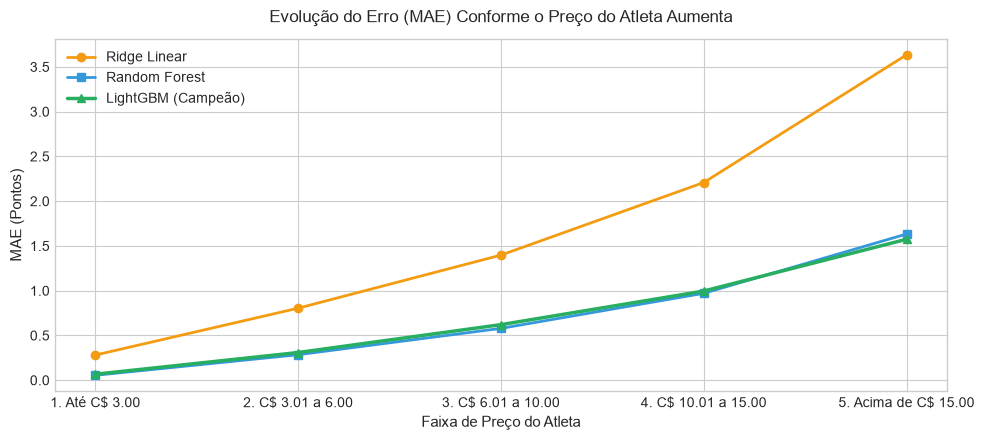

In [68]:
# Categorização por Faixas de Preço no Cartola
df_test_diag["faixa_preco"] = pd.cut(
    df_test_diag["preco_num"],
    bins=[0, 3, 6, 10, 15, 40],
    labels=["1. Até C$ 3.00", "2. C$ 3.01 a 6.00", "3. C$ 6.01 a 10.00", "4. C$ 10.01 a 15.00", "5. Acima de C$ 15.00"]
)

perf_preco = df_test_diag.groupby("faixa_preco").agg(
    Total_Registros=("pontos_num", "count"),
    Media_Real=("pontos_num", "mean"),
    MAE_Ridge=("erro_ridge", "mean"),
    MAE_RF=("erro_rf", "mean"),
    MAE_LightGBM=("erro_lgbm", "mean")
)
perf_preco["Reducao_Erro_LGBM_vs_Ridge (%)"] = ((perf_preco["MAE_Ridge"] - perf_preco["MAE_LightGBM"]) / perf_preco["MAE_Ridge"]) * 100

print("=== 1. PERFORMANCE POR FAIXA DE PREÇO: COMPARATIVO ENTRE MODELOS ===")
display(perf_preco.round(3))

# Tabela por Status Pré-Jogo
perf_status = df_test_diag.groupby("status_pre").agg(
    Total_Registros=("pontos_num", "count"),
    Jogaram=("entrou_em_campo", "sum"),
    Media_Real=("pontos_num", "mean"),
    MAE_Ridge=("erro_ridge", "mean"),
    MAE_RF=("erro_rf", "mean"),
    MAE_LightGBM=("erro_lgbm", "mean")
)
print("\n=== 2. PERFORMANCE POR STATUS PRÉ-JOGO: COMPARATIVO ENTRE MODELOS ===")
display(perf_status.round(3))

# Gráfico de Linhas: MAE por Faixa de Preço
plt.figure(figsize=(10, 4.5))
plt.plot(perf_preco.index.astype(str), perf_preco["MAE_Ridge"], marker="o", label="Ridge Linear", color="#f39c12", linewidth=2)
plt.plot(perf_preco.index.astype(str), perf_preco["MAE_RF"], marker="s", label="Random Forest", color="#3498db", linewidth=2)
plt.plot(perf_preco.index.astype(str), perf_preco["MAE_LightGBM"], marker="^", label="LightGBM (Campeão)", color="#27ae60", linewidth=2.5)
plt.title("Evolução do Erro (MAE) Conforme o Preço do Atleta Aumenta", fontsize=12, pad=12)
plt.xlabel("Faixa de Preço do Atleta", fontsize=11)
plt.ylabel("MAE (Pontos)", fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

#### 6.3 Onde Todos os Modelos Sofrem Mais? (Diagnóstico por Faixa de Pontuação Real)

Segmentamos o conjunto de teste em 4 faixas de pontuação real para demonstrar onde se concentram os erros dos modelos:
* **1. Negativa ($< 0\text{ pts}$):** Penalidades por cartões, faltas ou gols contra.
* **2. Típica Baixa ($0$ a $5\text{ pts}$):** $82\%$ da base (não-jogantes e atletas com scouts moderados).
* **3. Boa ($5$ a $10\text{ pts}$):** Atletas titulares com saldo de gol ou participações ofensivas.
* **4. 'Mitada' Extrema ($> 10\text{ pts}$):** Jogos fora da curva com múltiplos gols ou defesas de pênalti.

In [69]:
# 2. Performance por Faixa de Pontuação Real
df_test_diag["faixa_pontos_real"] = pd.cut(
    df_test_diag["pontos_num"],
    bins=[-20, 0, 5, 10, 35],
    labels=["1. Negativa (< 0 pts)", "2. Típica Baixa (0 a 5 pts)", "3. Boa (5 a 10 pts)", "4. 'Mitada' Extrema (> 10 pts)"]
)

diag_faixa = df_test_diag.groupby("faixa_pontos_real").agg(
    Total_Registros=("pontos_num", "count"),
    Proporcao_Base=("pontos_num", lambda x: (len(x) / len(df_test_diag)) * 100),
    Media_Real=("pontos_num", "mean"),
    Media_Pred_RF=("y_rf", "mean"),
    Media_Pred_LGBM=("y_lgbm", "mean"),
    MAE_Ridge=("erro_ridge", "mean"),
    MAE_RF=("erro_rf", "mean"),
    MAE_LGBM=("erro_lgbm", "mean"),
    Mediana_Erro_LGBM=("erro_lgbm", "median"),
    Erro_Maximo_LGBM=("erro_lgbm", "max")
)

print("=== DIAGNÓSTICO POR FAIXA DE PONTUAÇÃO REAL (ONDE TODOS OS MODELOS ERRAM MAIS) ===")
display(diag_faixa.round(3))

=== DIAGNÓSTICO POR FAIXA DE PONTUAÇÃO REAL (ONDE TODOS OS MODELOS ERRAM MAIS) ===


Total_Registros  Proporcao_Base  Media_Real  \
faixa_pontos_real                                                             
1. Negativa (< 0 pts)                     18255         65.5900     -0.0560   
2. Típica Baixa (0 a 5 pts)                6314         22.6860      2.2850   
3. Boa (5 a 10 pts)                        2423          8.7060      7.1790   
4. 'Mitada' Extrema (> 10 pts)              840          3.0180     13.1920   

                                Media_Pred_RF  Media_Pred_LGBM  MAE_Ridge  \
faixa_pontos_real                                                           
1. Negativa (< 0 pts)                  0.0310           0.0420     0.6350   
2. Típica Baixa (0 a 5 pts)            2.0100           2.0360     1.0550   
3. Boa (5 a 10 pts)                    6.5610           6.4710     2.0130   
4. 'Mitada' Extrema (> 10 pts)        11.6610          11.6170     4.3350   

                                MAE_RF  MAE_LGBM  Mediana_Erro_LGBM  \
faixa_pontos_real                                                     
1. Negativa (< 0 pts)           0.0940    0.1240             0.0180   
2. Típica Baixa (0 a 5 pts)     0.7020    0.7000             0.5220   
3. Boa (5 a 10 pts)             1.0760    1.1130             0.8560   
4. 'Mitada' Extrema (> 10 pts)  1.8190    1.9030             1.6070   

                                Erro_Maximo_LGBM  
faixa_pontos_real                                 
1. Negativa (< 0 pts)                     9.4100  
2. Típica Baixa (0 a 5 pts)               7.6050  
3. Boa (5 a 10 pts)                       7.8200  
4. 'Mitada' Extrema (> 10 pts)           10.8720

#### 6.4 Painel Gráfico 4-em-1 de Diagnóstico Residual

Apresentamos os 4 painéis fundamentais de diagnóstico de resíduos e calibração dos modelos:

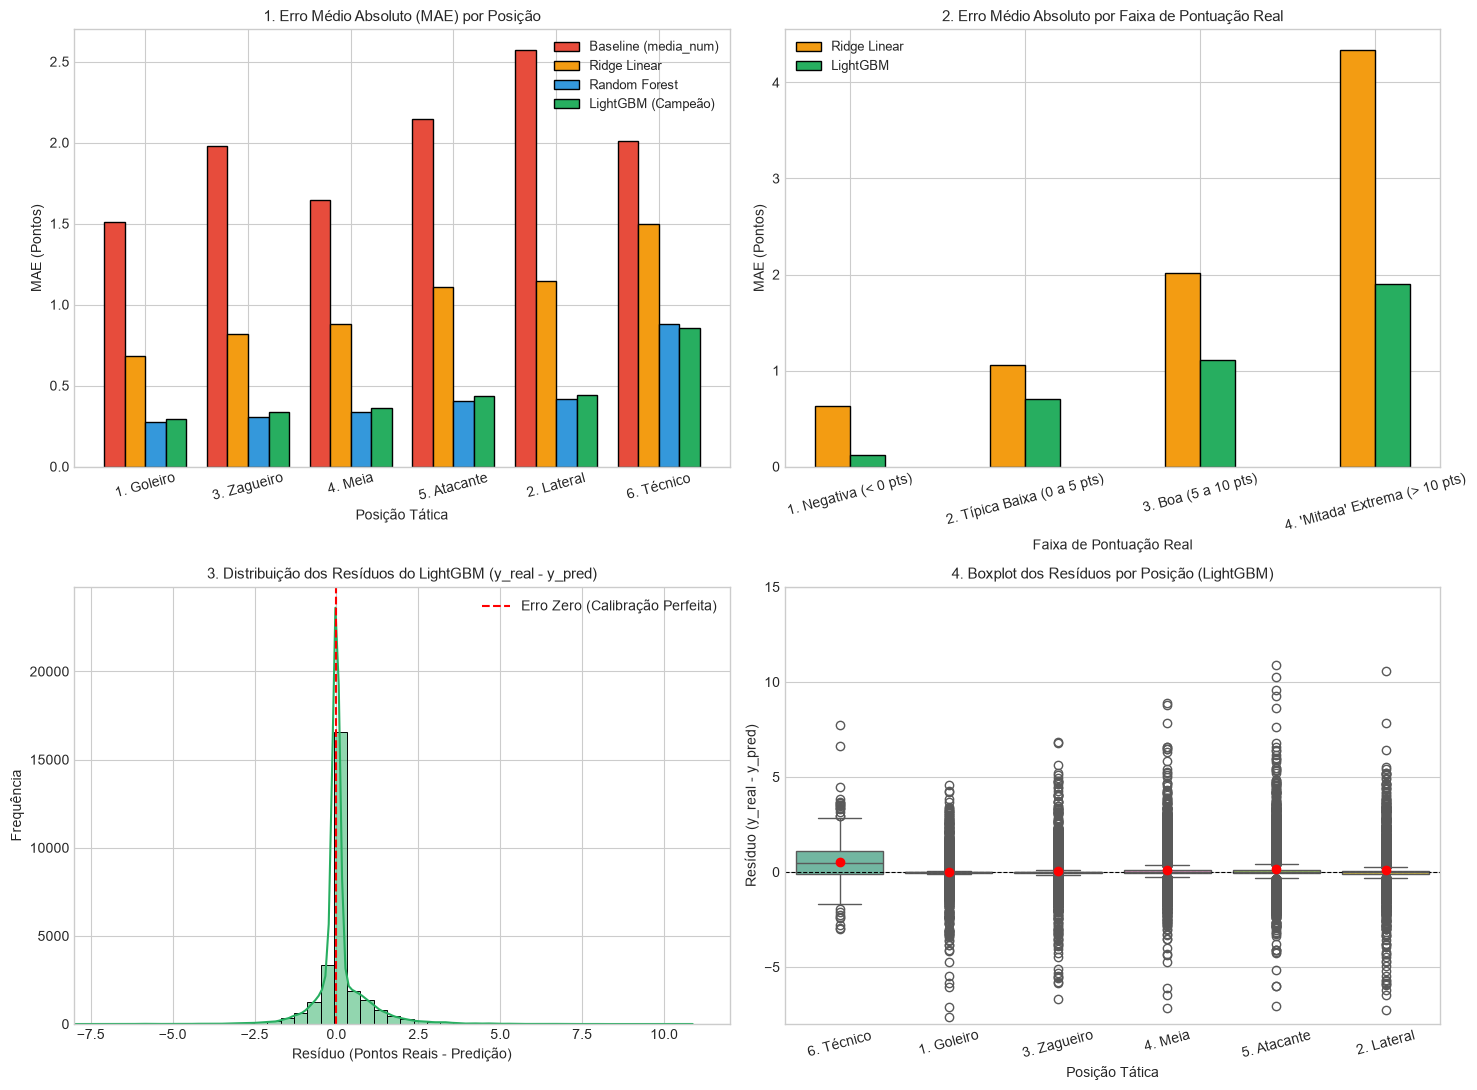

In [70]:
# Gráficos Diagnósticos: 4 Painéis de Análise Residual
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Painel 1: MAE por Posição Comparando Modelos
posicoes_plot = diag_pos.index
x_pos = np.arange(len(posicoes_plot))
w = 0.20
axes[0, 0].bar(x_pos - 1.5*w, diag_pos["MAE_Baseline"], w, label="Baseline (media_num)", color="#e74c3c", edgecolor="black")
axes[0, 0].bar(x_pos - 0.5*w, diag_pos["MAE_Ridge"], w, label="Ridge Linear", color="#f39c12", edgecolor="black")
axes[0, 0].bar(x_pos + 0.5*w, diag_pos["MAE_RandomForest"], w, label="Random Forest", color="#3498db", edgecolor="black")
axes[0, 0].bar(x_pos + 1.5*w, diag_pos["MAE_LightGBM"], w, label="LightGBM (Campeão)", color="#27ae60", edgecolor="black")
axes[0, 0].set_title("1. Erro Médio Absoluto (MAE) por Posição", fontsize=11)
axes[0, 0].set_xlabel("Posição Tática")
axes[0, 0].set_ylabel("MAE (Pontos)")
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(posicoes_plot, rotation=15, fontsize=10)
axes[0, 0].legend(fontsize=9)

# Painel 2: MAE por Faixa de Pontuação Real
faixas_plot = diag_faixa.index.astype(str)
x_faixa = np.arange(len(faixas_plot))
axes[0, 1].bar(x_faixa - 0.5*w, diag_faixa["MAE_Ridge"], w, label="Ridge Linear", color="#f39c12", edgecolor="black")
axes[0, 1].bar(x_faixa + 0.5*w, diag_faixa["MAE_LGBM"], w, label="LightGBM", color="#27ae60", edgecolor="black")
axes[0, 1].set_title("2. Erro Médio Absoluto por Faixa de Pontuação Real", fontsize=11)
axes[0, 1].set_xlabel("Faixa de Pontuação Real")
axes[0, 1].set_ylabel("MAE (Pontos)")
axes[0, 1].set_xticks(x_faixa)
axes[0, 1].set_xticklabels(faixas_plot, rotation=15, fontsize=10)
axes[0, 1].legend(fontsize=9)

# Painel 3: Distribuição dos Resíduos (y_real - y_pred)
sns.histplot(df_test_diag["residuo_lgbm"], kde=True, bins=50, color="#27ae60", ax=axes[1, 0])
axes[1, 0].axvline(0, color="red", linestyle="--", label="Erro Zero (Calibração Perfeita)")
axes[1, 0].set_title("3. Distribuição dos Resíduos do LightGBM (y_real - y_pred)", fontsize=11)
axes[1, 0].set_xlabel("Resíduo (Pontos Reais - Predição)")
axes[1, 0].set_ylabel("Frequência")
axes[1, 0].set_xlim(-8, 12)
axes[1, 0].legend()

# Painel 4: Boxplot de Resíduos por Posição
sns.boxplot(data=df_test_diag, x="posicao_nome", y="residuo_lgbm", palette="Set2", ax=axes[1, 1], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red"})
axes[1, 1].axhline(0, color="black", linestyle="--", lw=0.8)
axes[1, 1].set_title("4. Boxplot dos Resíduos por Posição (LightGBM)", fontsize=11)
axes[1, 1].set_xlabel("Posição Tática")
axes[1, 1].set_ylabel("Resíduo (y_real - y_pred)")
axes[1, 1].set_ylim(-8, 15)
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### 7. Exportação dos Artefatos de Modelagem e Base Completa de Predições

Exportamos todos os modelos treinados na base completa e o arquivo `data/processed/predicoes_modelos_2024.parquet` contendo as predições de **todos os 28.568 atletas** da temporada 2024.

In [71]:
print("=== EXPORTANDO MODELOS SERIALIZADOS (.JOBLIB) ===")

# Salva o Pré-processador Linear
joblib.dump(preprocessor_linear, MODELS_DIR / "preprocessor_linear.joblib")
print(f"Pré-processador Linear salvo em: {MODELS_DIR / 'preprocessor_linear.joblib'}")

# Salva Modelos Lineares
for nome, mod in modelos_lineares.items():
    slug = nome.lower().replace(" ", "_").replace("(", "").replace(")", "")
    caminho = MODELS_DIR / f"modelo_{slug}.joblib"
    joblib.dump(mod, caminho)
    print(f"Modelo '{nome}' salvo em: {caminho} ({caminho.stat().st_size / 1024:.2f} KB)")

# Salva Modelos de Árvore
for nome, mod in modelos_arvores.items():
    slug = nome.lower().replace(" ", "_")
    caminho = MODELS_DIR / f"modelo_{slug}.joblib"
    joblib.dump(mod, caminho)
    print(f"Modelo '{nome}' salvo em: {caminho} ({caminho.stat().st_size / (1024*1024):.2f} MB)")

# Montagem e Exportação da Base Completa de Predições do Teste (Safra 2024: 28.568 linhas)
df_predicoes_export = df_features[test_mask][[
    "ano", "rodada_id", "atleta_id", "apelido", "clube_id", "posicao_id", "posicao_nome",
    "status_pre", "entrou_em_campo", "preco_num", "home_dummy", "opponent", "pontos_num"
]].copy()

for k, v in predicoes_dict.items():
    if k != "y_real":
        df_predicoes_export[k] = v

CAMINHO_PREDICOES_PARQUET = DATA_PROCESSED_DIR / "predicoes_modelos_2024.parquet"
df_predicoes_export.to_parquet(CAMINHO_PREDICOES_PARQUET, index=False)

print("\n=== BASE COMPLETA DE PREDIÇÕES EXPORTADA COM SUCESSO! ===")
print(f"Arquivo salvo em: {CAMINHO_PREDICOES_PARQUET} ({CAMINHO_PREDICOES_PARQUET.stat().st_size / (1024*1024):.2f} MB)")
print(f"Dimensões da Base de Predições: {df_predicoes_export.shape[0]:,} linhas x {df_predicoes_export.shape[1]} colunas")
print(f"Total de nulos: {df_predicoes_export.isna().sum().sum()}")
print("\nAmostra das predições exportadas:")
display(df_predicoes_export.head(10))

=== EXPORTANDO MODELOS SERIALIZADOS (.JOBLIB) ===
Pré-processador Linear salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/preprocessor_linear.joblib
Modelo 'Regressão Linear (OLS)' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_regressão_linear_ols.joblib (1.91 KB)
Modelo 'Ridge Regression (L2)' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_ridge_regression_l2.joblib (1.19 KB)
Modelo 'Random Forest' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_random_forest.joblib (14.83 MB)
Modelo 'LightGBM' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_lightgbm.joblib (0.42 MB)
Modelo 'XGBoost' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_xgboost.joblib (0.41 MB)
Modelo 'CatBoost' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_c

ano  rodada_id  atleta_id            apelido  clube_id  posicao_id  \
87781  2025          1      10004  Elias Bittencourt       105           6   
87782  2025          6      10004  Elias Bittencourt       113           6   
87783  2025          7      10004  Elias Bittencourt       113           6   
87784  2025          8      10004  Elias Bittencourt       113           6   
87785  2025          9      10004  Elias Bittencourt       113           6   
87786  2025         10      10004  Elias Bittencourt       113           6   
87787  2025         11      10004  Elias Bittencourt       113           6   
87788  2025         12      10004  Elias Bittencourt       113           6   
87789  2025         13      10004  Elias Bittencourt       113           6   
87790  2025         14      10004  Elias Bittencourt       113           6   

      posicao_nome status_pre  entrou_em_campo  preco_num  home_dummy  \
87781   6. Técnico   Provável             True     9.0400           0   
87782   6. Técnico   Provável             True     9.5300           0   
87783   6. Técnico   Provável             True    10.4400           1   
87784   6. Técnico   Provável             True     9.8500           1   
87785   6. Técnico   Provável             True     8.9400           0   
87786   6. Técnico   Provável             True     9.7400           1   
87787   6. Técnico   Provável             True    10.5200           0   
87788   6. Técnico   Provável             True     9.9000           1   
87789   6. Técnico   Provável             True     9.5700           0   
87790   6. Técnico       Nulo            False     9.5700           1   

       opponent  pontos_num  pred_baseline_media  pred_regressão_linear_ols  \
87781       125      2.4500               2.4500                     0.7232   
87782       116      4.1900               3.3200                     4.5202   
87783       109      8.9000               5.1800                     6.4632   
87784       110      5.4600               5.2500                     3.4903   
87785       108      2.0200               4.6000                     1.4761   
87786       104      6.8500               4.9800                     5.6001   
87787       115     10.6100               5.7800                     7.0851   
87788       103      5.2300               5.7100                     4.1862   
87789       112      3.3700               5.4500                     3.3250   
87790       125      0.0000               5.4500                     3.5363   

       pred_ridge_regression_l2  pred_random_forest  pred_lightgbm  \
87781                    0.7059              2.2601         3.0014   
87782                    4.5099              4.4790         4.5011   
87783                    6.4492              6.8282         7.1803   
87784                    3.4779              3.7581         4.0710   
87785                    1.4652              1.2214         0.8546   
87786                    5.5878              6.4703         6.3773   
87787                    7.0720             10.2051         9.0735   
87788                    4.1735              4.8334         4.6279   
87789                    3.3141              2.8667         3.1788   
87790                    3.5313              0.8805         0.9324   

       pred_xgboost  pred_catboost  
87781        2.8286         2.4945  
87782        4.5440         4.3734  
87783        7.0440         6.9800  
87784        4.0705         3.9033  
87785        1.0913         1.2711  
87786        6.2881         5.9579  
87787        9.3603         9.0120  
87788        4.7011         4.4449  
87789        3.3674         2.7047  
87790        0.7029         0.9606